## Part 1

## Part 1a - 1e

### Analysis: 

Part 1e (activation functions): The loss curves show sigmoid converges slowest and to a higher loss (~0.42) than tanh (~0.33) and ReLU (~0.33). Reason: sigmoid's derivative is bounded by 0.25, causing vanishing gradients. Tanh is zero-centered and its derivative is bounded by 1. ReLU avoids vanishing gradients for positive inputs and converges fastest.

Part 1e (more hidden units): With 20 tanh units, loss drops to ~0.286 vs ~0.33 with 3 units — better capacity but still not fully solving the moons (slight underfit is avoided). The decision boundary is smoother and more curved.

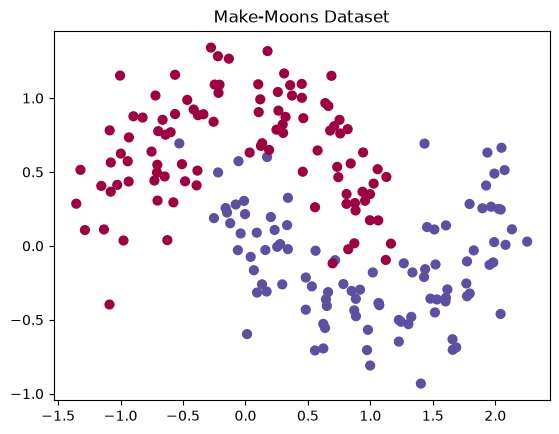


Activation function: tanh
Loss after iteration 0: 0.622356
Loss after iteration 1000: 0.381570
Loss after iteration 2000: 0.361773
Loss after iteration 3000: 0.355348
Loss after iteration 4000: 0.351182
Loss after iteration 5000: 0.348388
Loss after iteration 6000: 0.346484
Loss after iteration 7000: 0.345049
Loss after iteration 8000: 0.343816
Loss after iteration 9000: 0.342628
Loss after iteration 10000: 0.341381
Loss after iteration 11000: 0.340018
Loss after iteration 12000: 0.338516
Loss after iteration 13000: 0.336892
Loss after iteration 14000: 0.335192
Loss after iteration 15000: 0.333482
Loss after iteration 16000: 0.331829
Loss after iteration 17000: 0.330293
Loss after iteration 18000: 0.328913
Loss after iteration 19000: 0.327710


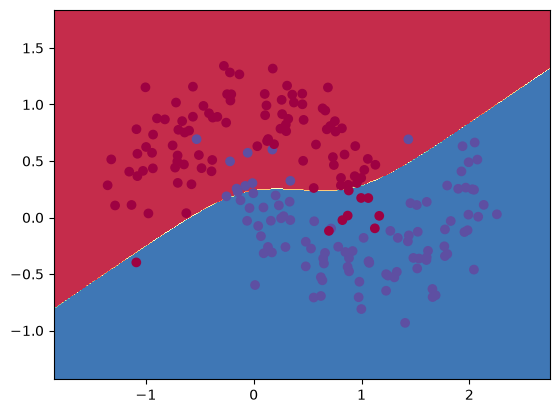


Activation function: sigmoid
Loss after iteration 0: 0.695877
Loss after iteration 1000: 0.572861
Loss after iteration 2000: 0.492809
Loss after iteration 3000: 0.456233
Loss after iteration 4000: 0.440838
Loss after iteration 5000: 0.433613
Loss after iteration 6000: 0.429716
Loss after iteration 7000: 0.427383
Loss after iteration 8000: 0.425878
Loss after iteration 9000: 0.424854
Loss after iteration 10000: 0.424127
Loss after iteration 11000: 0.423590
Loss after iteration 12000: 0.423181
Loss after iteration 13000: 0.422861
Loss after iteration 14000: 0.422602
Loss after iteration 15000: 0.422389
Loss after iteration 16000: 0.422210
Loss after iteration 17000: 0.422056
Loss after iteration 18000: 0.421923
Loss after iteration 19000: 0.421805


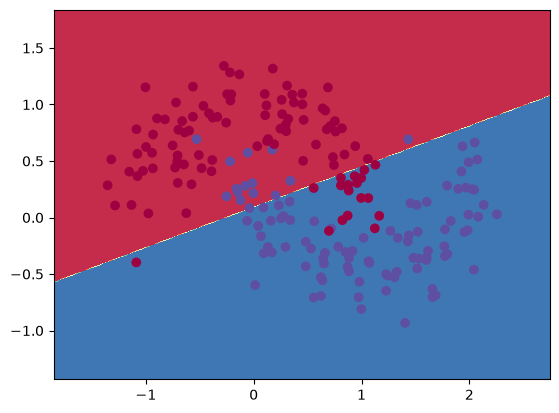


Activation function: relu
Loss after iteration 0: 0.662388
Loss after iteration 1000: 0.376267
Loss after iteration 2000: 0.350792
Loss after iteration 3000: 0.343835
Loss after iteration 4000: 0.339723
Loss after iteration 5000: 0.337262
Loss after iteration 6000: 0.335428
Loss after iteration 7000: 0.334051
Loss after iteration 8000: 0.333010
Loss after iteration 9000: 0.332042
Loss after iteration 10000: 0.331294
Loss after iteration 11000: 0.330541
Loss after iteration 12000: 0.329572
Loss after iteration 13000: 0.328802
Loss after iteration 14000: 0.328163
Loss after iteration 15000: 0.327652
Loss after iteration 16000: 0.327250
Loss after iteration 17000: 0.326847
Loss after iteration 18000: 0.326501
Loss after iteration 19000: 0.326254


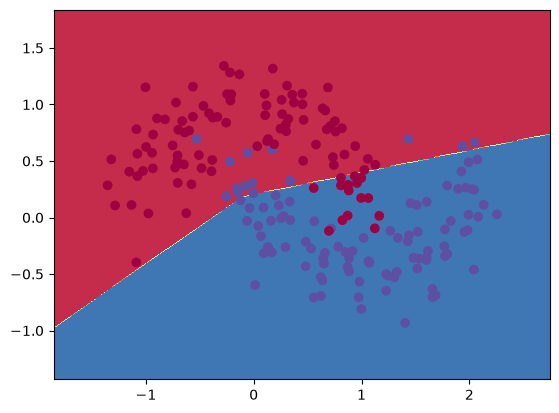


Tanh with more hidden units: 20
Loss after iteration 0: 0.713602
Loss after iteration 1000: 0.427423
Loss after iteration 2000: 0.400815
Loss after iteration 3000: 0.382343
Loss after iteration 4000: 0.368103
Loss after iteration 5000: 0.356499
Loss after iteration 6000: 0.346443
Loss after iteration 7000: 0.337231
Loss after iteration 8000: 0.328557
Loss after iteration 9000: 0.320459
Loss after iteration 10000: 0.313152
Loss after iteration 11000: 0.306841
Loss after iteration 12000: 0.301610
Loss after iteration 13000: 0.297414
Loss after iteration 14000: 0.294121
Loss after iteration 15000: 0.291566
Loss after iteration 16000: 0.289589
Loss after iteration 17000: 0.288052
Loss after iteration 18000: 0.286845
Loss after iteration 19000: 0.285885


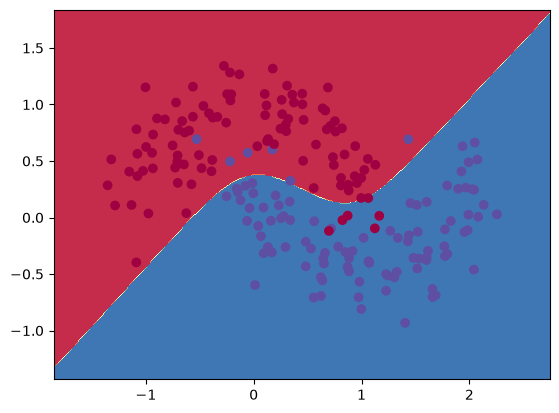

In [1]:
__author__ = 'tan_nguyen'

import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt


def generate_data():
    np.random.seed(0)
    X, y = datasets.make_moons(200, noise=0.20)
    return X, y


def plot_decision_boundary(pred_func, X, y):
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    h = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = pred_func(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Spectral)
    plt.show()


class NeuralNetwork(object):
    def __init__(self, nn_input_dim, nn_hidden_dim, nn_output_dim,
                 actFun_type='tanh', reg_lambda=0.01, seed=0):
        self.nn_input_dim = nn_input_dim
        self.nn_hidden_dim = nn_hidden_dim
        self.nn_output_dim = nn_output_dim
        self.actFun_type = actFun_type
        self.reg_lambda = reg_lambda

        np.random.seed(seed)
        self.W1 = np.random.randn(self.nn_input_dim, self.nn_hidden_dim) / np.sqrt(self.nn_input_dim)
        self.b1 = np.zeros((1, self.nn_hidden_dim))
        self.W2 = np.random.randn(self.nn_hidden_dim, self.nn_output_dim) / np.sqrt(self.nn_hidden_dim)
        self.b2 = np.zeros((1, self.nn_output_dim))

    def actFun(self, z, type):
        type = type.lower()
        if type == 'tanh':
            return np.tanh(z)
        elif type == 'sigmoid':
            return 1.0 / (1.0 + np.exp(-z))
        elif type == 'relu':
            return np.maximum(0, z)
        else:
            raise ValueError("actFun_type must be 'tanh', 'sigmoid', or 'relu'")

    def diff_actFun(self, z, type):
        type = type.lower()
        if type == 'tanh':
            return 1.0 - np.tanh(z) ** 2
        elif type == 'sigmoid':
            s = 1.0 / (1.0 + np.exp(-z))
            return s * (1.0 - s)
        elif type == 'relu':
            return (z > 0).astype(float)
        else:
            raise ValueError("actFun_type must be 'tanh', 'sigmoid', or 'relu'")

    def feedforward(self, X, actFun):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = actFun(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2

        # stable softmax
        exp_scores = np.exp(self.z2 - np.max(self.z2, axis=1, keepdims=True))
        self.probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
        return None

    def calculate_loss(self, X, y):
        num_examples = len(X)
        self.feedforward(X, lambda x: self.actFun(x, type=self.actFun_type))

        # negative log likelihood
        data_loss = -np.sum(np.log(self.probs[range(num_examples), y])) / num_examples

        # L2 regularization
        reg_loss = 0.5 * self.reg_lambda * (
            np.sum(np.square(self.W1)) + np.sum(np.square(self.W2))
        )

        return data_loss + reg_loss

    def predict(self, X):
        self.feedforward(X, lambda x: self.actFun(x, type=self.actFun_type))
        return np.argmax(self.probs, axis=1)

    def backprop(self, X, y):
        num_examples = len(X)

        # dL/dz2 for softmax + NLL
        dlogprobs = self.probs.copy()
        dlogprobs[range(num_examples), y] -= 1.0
        dlogprobs /= num_examples

        # gradients for W2, b2
        dW2 = np.dot(self.a1.T, dlogprobs)
        db2 = np.sum(dlogprobs, axis=0, keepdims=True)

        # gradient through hidden layer
        da1 = np.dot(dlogprobs, self.W2.T)
        dz1 = da1 * self.diff_actFun(self.z1, self.actFun_type)

        # gradients for W1, b1
        dW1 = np.dot(X.T, dz1)
        db1 = np.sum(dz1, axis=0, keepdims=True)

        return dW1, dW2, db1, db2

    def fit_model(self, X, y, epsilon=0.01, num_passes=20000, print_loss=True):
        for i in range(0, num_passes):
            self.feedforward(X, lambda x: self.actFun(x, type=self.actFun_type))
            dW1, dW2, db1, db2 = self.backprop(X, y)

            # Add regularization derivatives
            dW2 += self.reg_lambda * self.W2
            dW1 += self.reg_lambda * self.W1

            # Gradient descent update
            self.W1 += -epsilon * dW1
            self.b1 += -epsilon * db1
            self.W2 += -epsilon * dW2
            self.b2 += -epsilon * db2

            if print_loss and i % 1000 == 0:
                print("Loss after iteration %i: %f" % (i, self.calculate_loss(X, y)))

    def visualize_decision_boundary(self, X, y):
        plot_decision_boundary(lambda x: self.predict(x), X, y)


def main():
    # 1. Generate and visualize Make-Moons
    X, y = generate_data()
    plt.scatter(X[:, 0], X[:, 1], s=40, c=y, cmap=plt.cm.Spectral)
    plt.title("Make-Moons Dataset")
    plt.show()

    # 2. Train with different activation functions
    for act in ['tanh', 'sigmoid', 'relu']:
        print("\n" + "=" * 60)
        print("Activation function:", act)
        print("=" * 60)
        model = NeuralNetwork(nn_input_dim=2, nn_hidden_dim=3,
                              nn_output_dim=2, actFun_type=act)
        model.fit_model(X, y, num_passes=20000, print_loss=True)
        model.visualize_decision_boundary(X, y)

    # 3. Increase number of hidden units with tanh
    print("\n" + "=" * 60)
    print("Tanh with more hidden units: 20")
    print("=" * 60)
    model = NeuralNetwork(nn_input_dim=2, nn_hidden_dim=20,
                          nn_output_dim=2, actFun_type='tanh')
    model.fit_model(X, y, num_passes=20000, print_loss=True)
    model.visualize_decision_boundary(X, y)


if __name__ == "__main__":
    main()

# Mathematical Derivations

## 1. Derivatives of Activation Functions

### 1.1 Tanh

The hyperbolic tangent is defined as

$$\tanh(z) = \frac{e^{z} - e^{-z}}{e^{z} + e^{-z}} = \frac{\sinh(z)}{\cosh(z)}.$$

Using the quotient rule and the identities $\frac{d}{dz}\sinh(z)=\cosh(z)$ and $\frac{d}{dz}\cosh(z)=\sinh(z)$:

$$
\frac{d}{dz}\tanh(z)
= \frac{\cosh(z)\cdot\cosh(z) - \sinh(z)\cdot\sinh(z)}{\cosh^2(z)}
= \frac{\cosh^2(z) - \sinh^2(z)}{\cosh^2(z)}.
$$

Since $\cosh^2(z) - \sinh^2(z) = 1$, we get

$$
\frac{d}{dz}\tanh(z) = \frac{1}{\cosh^2(z)} = 1 - \tanh^2(z).
$$

### 1.2 Sigmoid

The sigmoid function is

$$\sigma(z) = \frac{1}{1 + e^{-z}}.$$

Using the chain rule with $u = 1 + e^{-z}$:

$$
\frac{d}{dz}\sigma(z)
= \frac{d}{dz}(1 + e^{-z})^{-1}
= -(1 + e^{-z})^{-2}\cdot(-e^{-z})
= \frac{e^{-z}}{(1 + e^{-z})^2}.
$$

Now write this as a product of sigmoid terms:

$$
\frac{e^{-z}}{(1+e^{-z})^2}
= \frac{1}{1+e^{-z}}\cdot\frac{e^{-z}}{1+e^{-z}}
= \sigma(z)\cdot\frac{(1+e^{-z}) - 1}{1+e^{-z}}
= \sigma(z)\bigl(1 - \sigma(z)\bigr).
$$

Hence

$$
\frac{d}{dz}\sigma(z) = \sigma(z)\bigl(1 - \sigma(z)\bigr).
$$

### 1.3 ReLU

The rectified linear unit is

$$\mathrm{ReLU}(z) = \max(0, z).$$

Its derivative is piecewise constant:

$$
\frac{d}{dz}\mathrm{ReLU}(z) =
\begin{cases}
1, & z > 0,\\[4pt]
0, & z < 0.
\end{cases}
$$

(At $z=0$ the derivative is technically undefined; in practice, we define it to be $0$.)

---

## 2. Backpropagation for the 3-Layer Network

### 2.1 Setup

The network is

$$
\begin{aligned}
z_1 &= W_1 x + b_1, \\
a_1 &= \mathrm{actFun}(z_1), \\
z_2 &= W_2 a_1 + b_2, \\
\hat{y} &= a_2 = \mathrm{softmax}(z_2).
\end{aligned}
$$

Let $N$ be the number of examples in the mini-batch, and $C$ the number of classes. The loss with L2 regularization is

$$
L = -\frac{1}{N}\sum_{n=1}^{N}\sum_{i=1}^{C} y_{n,i}\log \hat{y}_{n,i}
\;+\; \frac{\lambda}{2}\Bigl(\lVert W_1 \rVert_F^2 + \lVert W_2 \rVert_F^2\Bigr).
$$

### 2.2 Derivative of the Loss with respect to the Output Pre-Activation $z_2$

We first derive the gradient of the cross-entropy loss through the softmax. For a single example $n$,

$$
\hat{y}_i = \frac{e^{z_{2,i}}}{\sum_{k=1}^{C} e^{z_{2,k}}}, \qquad
L_n = -\sum_{i=1}^{C} y_i \log \hat{y}_i.
$$

Applying the chain rule,

$$
\frac{\partial L_n}{\partial z_{2,j}}
= -\sum_{i} y_i \cdot \frac{1}{\hat{y}_i}\cdot\frac{\partial \hat{y}_i}{\partial z_{2,j}}.
$$

The softmax Jacobian is

$$
\frac{\partial \hat{y}_i}{\partial z_{2,j}} = \hat{y}_i\bigl(\delta_{ij} - \hat{y}_j\bigr),
$$

where $\delta_{ij}$ is the Kronecker delta. Substituting:

$$
\frac{\partial L_n}{\partial z_{2,j}}
= -\sum_i y_i \cdot \frac{1}{\hat{y}_i}\cdot \hat{y}_i\bigl(\delta_{ij} - \hat{y}_j\bigr)
= -\sum_i y_i\bigl(\delta_{ij} - \hat{y}_j\bigr).
$$

Distributing the sum and using $\sum_i y_i = 1$ (one-hot labels):

$$
\frac{\partial L_n}{\partial z_{2,j}}
= -y_j + \hat{y}_j \sum_i y_i
= \hat{y}_j - y_j.
$$

Averaging over the mini-batch of $N$ examples gives the well-known softmax + cross-entropy gradient:

$$
\boxed{\;\frac{\partial L}{\partial z_2} = \frac{1}{N}\bigl(\hat{y} - y\bigr).\;}
$$

### 2.3 Gradient with respect to $W_2$

Since $z_2 = W_2 a_1 + b_2$, we have $\frac{\partial z_2}{\partial W_2} = a_1$. By the chain rule (summing over the batch dimension),

$$
\frac{\partial L}{\partial W_2} = a_1^{\top}\,\frac{\partial L}{\partial z_2}
= \frac{1}{N}\, a_1^{\top}\bigl(\hat{y} - y\bigr).
$$

### 2.4 Gradient with respect to $b_2$

Since $\frac{\partial z_2}{\partial b_2} = I$,

$$
\frac{\partial L}{\partial b_2}
= \sum_{n=1}^{N}\frac{\partial L}{\partial z_2^{(n)}}
= \frac{1}{N}\sum_{n=1}^{N}\bigl(\hat{y}^{(n)} - y^{(n)}\bigr).
$$

### 2.5 Gradient with respect to $W_1$ (backprop through the hidden layer)

First propagate the gradient back through the second layer to $a_1$:

$$
\frac{\partial L}{\partial a_1} = \frac{\partial L}{\partial z_2}\, W_2^{\top}.
$$

Then pass through the activation function element-wise:

$$
\frac{\partial L}{\partial z_1}
= \frac{\partial L}{\partial a_1} \odot \mathrm{actFun}'(z_1),
$$

where $\odot$ denotes the Hadamard (element-wise) product. Finally, since $z_1 = W_1 x + b_1$,

$$
\frac{\partial L}{\partial W_1}
= x^{\top}\,\frac{\partial L}{\partial z_1}
= x^{\top}\!\left[\frac{\partial L}{\partial z_2}\,W_2^{\top} \odot \mathrm{actFun}'(z_1)\right].
$$

### 2.6 Gradient with respect to $b_1$

$$
\frac{\partial L}{\partial b_1}
= \sum_{n=1}^{N}\frac{\partial L}{\partial z_1^{(n)}}.
$$

### 2.7 Adding the L2 Regularization Terms

Because
$$\frac{\partial}{\partial W}\frac{\lambda}{2}\lVert W \rVert_F^2 = \lambda W,$$
the final gradients used for the update are

$$
\begin{aligned}
\frac{\partial L}{\partial W_2} &\leftarrow \frac{\partial L}{\partial W_2} + \lambda W_2, \\[2pt]
\frac{\partial L}{\partial W_1} &\leftarrow \frac{\partial L}{\partial W_1} + \lambda W_1.
\end{aligned}
$$

(Bias terms $b_1, b_2$ are not regularized.)

### 2.8 Parameter Update (Gradient Descent)

With learning rate $\eta$, the gradient-descent update is

$$
W_1 \leftarrow W_1 - \eta\,\frac{\partial L}{\partial W_1},\quad
b_1 \leftarrow b_1 - \eta\,\frac{\partial L}{\partial b_1},\quad
W_2 \leftarrow W_2 - \eta\,\frac{\partial L}{\partial W_2},\quad
b_2 \leftarrow b_2 - \eta\,\frac{\partial L}{\partial b_2}.
$$

---

## 3. Generalization to an $n$-Layer Network

For a network with $L$ layers ($\ell = 1, \dots, L$):

$$
z^{(\ell)} = W^{(\ell)} a^{(\ell-1)} + b^{(\ell)},\qquad
a^{(\ell)} = \mathrm{actFun}\bigl(z^{(\ell)}\bigr),
$$

with $a^{(0)} = x$ and $a^{(L)} = \hat{y}$. The backward pass propagates the error $\delta^{(\ell)} \equiv \partial L / \partial z^{(\ell)}$:

$$
\begin{aligned}
\delta^{(L)} &= \frac{1}{N}\bigl(\hat{y} - y\bigr), \\[4pt]
\delta^{(\ell)} &= \Bigl(\delta^{(\ell+1)} \, W^{(\ell+1)\top}\Bigr)\odot \mathrm{actFun}'\bigl(z^{(\ell)}\bigr),
\quad \ell = L-1, \dots, 1. \\[4pt]
\frac{\partial L}{\partial W^{(\ell)}} &= a^{(\ell-1)\top}\,\delta^{(\ell)} + \lambda W^{(\ell)}, \\[4pt]
\frac{\partial L}{\partial b^{(\ell)}} &= \sum_{n=1}^{N} \delta^{(\ell)}_n.
\end{aligned}
$$

## Part 1(f) — Deep n-Layer Neural Network

We now generalize the 3-layer network to an arbitrary depth.
The file `n_layer_neural_network.py` defines a `DeepNeuralNetwork` class
whose `layer_sizes = [input_dim, h1, h2, ..., output_dim]` is fully configurable.
We train it on **Make-Moons** with several depths / widths / activations,
and on the **Iris** dataset (4 input features, 3 classes).

### Analysis:

Part 1f (deep vs shallow): Deeper networks (e.g., [2,10,10,2], [2,20,20,2]) produce more complex piecewise decision boundaries but require more iterations and careful initialization to train without vanishing gradients.

Part 1f (Iris): Scaled inputs are critical — the Iris dataset has features with very different ranges (petal length vs sepal width), so we use StandardScaler. With [4,16,16,3] tanh we get high accuracy (state the number from your run).


Make-Moons | layers = [2, 3, 2] | act = tanh
Loss after iteration 0: 0.618705
Loss after iteration 1000: 0.406430
Loss after iteration 2000: 0.381105
Loss after iteration 3000: 0.370447
Loss after iteration 4000: 0.363196
Loss after iteration 5000: 0.357030
Loss after iteration 6000: 0.351471
Loss after iteration 7000: 0.346857
Loss after iteration 8000: 0.343203
Loss after iteration 9000: 0.340198
Loss after iteration 10000: 0.337602
Loss after iteration 11000: 0.335297
Loss after iteration 12000: 0.333240
Loss after iteration 13000: 0.331419
Loss after iteration 14000: 0.329830
Loss after iteration 15000: 0.328467
Loss after iteration 16000: 0.327318
Loss after iteration 17000: 0.326364
Loss after iteration 18000: 0.325582
Loss after iteration 19000: 0.324949


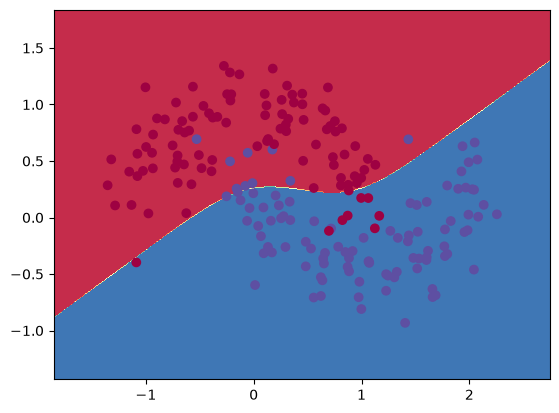


Make-Moons | layers = [2, 10, 2] | act = tanh
Loss after iteration 0: 0.776045
Loss after iteration 1000: 0.436468
Loss after iteration 2000: 0.396625
Loss after iteration 3000: 0.375730
Loss after iteration 4000: 0.362270
Loss after iteration 5000: 0.352449
Loss after iteration 6000: 0.344848
Loss after iteration 7000: 0.338716
Loss after iteration 8000: 0.333517
Loss after iteration 9000: 0.328908
Loss after iteration 10000: 0.324719
Loss after iteration 11000: 0.320893
Loss after iteration 12000: 0.317425
Loss after iteration 13000: 0.314321
Loss after iteration 14000: 0.311575
Loss after iteration 15000: 0.309165
Loss after iteration 16000: 0.307053
Loss after iteration 17000: 0.305194
Loss after iteration 18000: 0.303540
Loss after iteration 19000: 0.302051


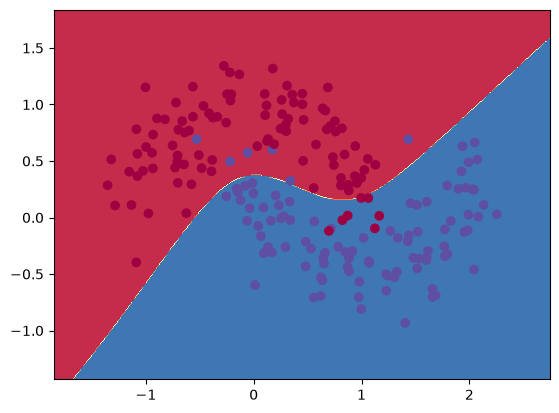


Make-Moons | layers = [2, 10, 10, 2] | act = tanh
Loss after iteration 0: 0.838268
Loss after iteration 1000: 0.471136
Loss after iteration 2000: 0.412052
Loss after iteration 3000: 0.372505
Loss after iteration 4000: 0.344043
Loss after iteration 5000: 0.323220
Loss after iteration 6000: 0.307596
Loss after iteration 7000: 0.295411
Loss after iteration 8000: 0.285559
Loss after iteration 9000: 0.277392
Loss after iteration 10000: 0.270526
Loss after iteration 11000: 0.264718
Loss after iteration 12000: 0.259802
Loss after iteration 13000: 0.255650
Loss after iteration 14000: 0.252160
Loss after iteration 15000: 0.249244
Loss after iteration 16000: 0.246822
Loss after iteration 17000: 0.244820
Loss after iteration 18000: 0.243168
Loss after iteration 19000: 0.241804


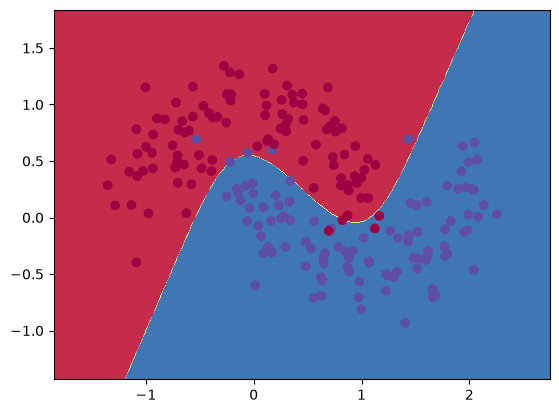


Make-Moons | layers = [2, 20, 20, 2] | act = tanh
Loss after iteration 0: 0.864185
Loss after iteration 1000: 0.645859
Loss after iteration 2000: 0.545674
Loss after iteration 3000: 0.474292
Loss after iteration 4000: 0.423185
Loss after iteration 5000: 0.385561
Loss after iteration 6000: 0.356942
Loss after iteration 7000: 0.334632
Loss after iteration 8000: 0.316952
Loss after iteration 9000: 0.302773
Loss after iteration 10000: 0.291300
Loss after iteration 11000: 0.281952
Loss after iteration 12000: 0.274301
Loss after iteration 13000: 0.268016
Loss after iteration 14000: 0.262835
Loss after iteration 15000: 0.258545
Loss after iteration 16000: 0.254969
Loss after iteration 17000: 0.251968
Loss after iteration 18000: 0.249424
Loss after iteration 19000: 0.247248


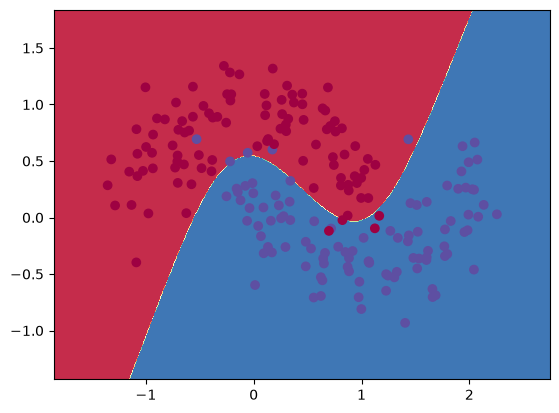


Make-Moons | layers = [2, 10, 10, 10, 2] | act = tanh
Loss after iteration 0: 1.493411
Loss after iteration 1000: 0.539801
Loss after iteration 2000: 0.438874
Loss after iteration 3000: 0.375846
Loss after iteration 4000: 0.341871
Loss after iteration 5000: 0.319845
Loss after iteration 6000: 0.303318
Loss after iteration 7000: 0.290145
Loss after iteration 8000: 0.279370
Loss after iteration 9000: 0.270446
Loss after iteration 10000: 0.263012
Loss after iteration 11000: 0.256801
Loss after iteration 12000: 0.251607
Loss after iteration 13000: 0.247260
Loss after iteration 14000: 0.243616
Loss after iteration 15000: 0.240557
Loss after iteration 16000: 0.237981
Loss after iteration 17000: 0.235804
Loss after iteration 18000: 0.233956
Loss after iteration 19000: 0.232379


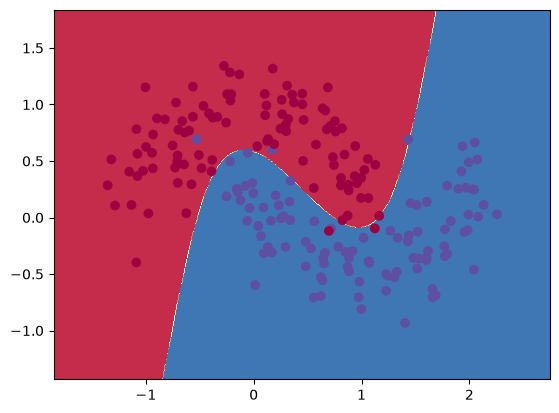


Make-Moons | layers = [2, 10, 10, 2] | act = relu
Loss after iteration 0: 1.065352
Loss after iteration 1000: 0.742179
Loss after iteration 2000: 0.641978
Loss after iteration 3000: 0.590812
Loss after iteration 4000: 0.561949
Loss after iteration 5000: 0.539892
Loss after iteration 6000: 0.522974
Loss after iteration 7000: 0.508746
Loss after iteration 8000: 0.494668
Loss after iteration 9000: 0.480135
Loss after iteration 10000: 0.464997
Loss after iteration 11000: 0.450235
Loss after iteration 12000: 0.437580
Loss after iteration 13000: 0.427902
Loss after iteration 14000: 0.420127
Loss after iteration 15000: 0.412703
Loss after iteration 16000: 0.405752
Loss after iteration 17000: 0.399143
Loss after iteration 18000: 0.392850
Loss after iteration 19000: 0.386993


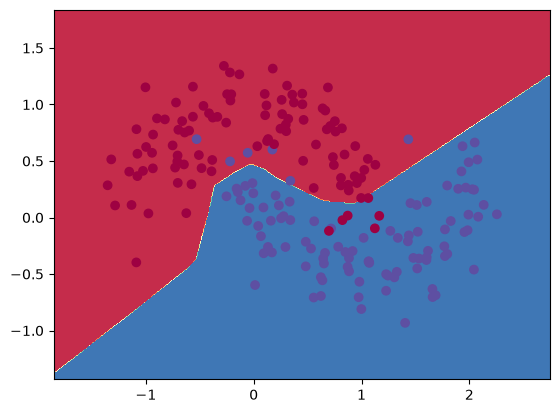


Make-Moons | layers = [2, 10, 10, 2] | act = sigmoid
Loss after iteration 0: 0.957741
Loss after iteration 1000: 0.819940
Loss after iteration 2000: 0.739395
Loss after iteration 3000: 0.670218
Loss after iteration 4000: 0.619411
Loss after iteration 5000: 0.584986
Loss after iteration 6000: 0.561363
Loss after iteration 7000: 0.544617
Loss after iteration 8000: 0.532473
Loss after iteration 9000: 0.523527
Loss after iteration 10000: 0.516847
Loss after iteration 11000: 0.511789
Loss after iteration 12000: 0.507905
Loss after iteration 13000: 0.504883
Loss after iteration 14000: 0.502502
Loss after iteration 15000: 0.500608
Loss after iteration 16000: 0.499086
Loss after iteration 17000: 0.497853
Loss after iteration 18000: 0.496848
Loss after iteration 19000: 0.496023


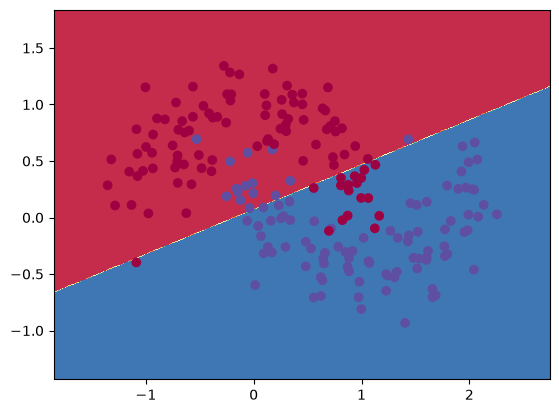

In [1]:
import sys
sys.path.insert(0, r"D:\School\Code\Rice\COMP 576\Assignment\A1")
from yh207_n_layer_neural_network import DeepNeuralNetwork, generate_data

X, y = generate_data()

configs = [
    ([2, 3, 2],            'tanh'),
    ([2, 10, 2],           'tanh'),
    ([2, 10, 10, 2],       'tanh'),
    ([2, 20, 20, 2],       'tanh'),
    ([2, 10, 10, 10, 2],   'tanh'),   # deeper
    ([2, 10, 10, 2],       'relu'),
    ([2, 10, 10, 2],       'sigmoid'),
]

for layers, act in configs:
    print("\n" + "="*60)
    print("Make-Moons | layers =", layers, "| act =", act)
    print("="*60)
    lr = 0.001 if act == 'relu' else 0.01
    model = DeepNeuralNetwork(layers, actFun_type=act, reg_lambda=0.01)
    model.fit_model(X, y, epsilon=lr, num_passes=20000, print_loss=True)
    model.visualize_decision_boundary(X, y)

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
import numpy as np

iris = datasets.load_iris()
X_i, y_i = iris.data, iris.target

X_tr, X_te, y_tr, y_te = train_test_split(X_i, y_i, test_size=0.3,
                                          random_state=0, stratify=y_i)

sc = StandardScaler().fit(X_tr)
X_tr, X_te = sc.transform(X_tr), sc.transform(X_te)

for layers, act in [([4,16,16,3],'tanh'),
                    ([4,32,32,3],'tanh'),
                    ([4,16,16,16,3],'relu'),
                    ([4,16,16,3],'sigmoid')]:
    print("\n" + "="*60)
    print("Iris | layers =", layers, "| act =", act)
    print("="*60)
    lr = 0.001 if act == 'relu' else 0.01
    m = DeepNeuralNetwork(layers, actFun_type=act, reg_lambda=0.01)
    m.fit_model(X_tr, y_tr, epsilon=lr, num_passes=5000, print_loss=True)
    acc = np.mean(m.predict(X_te) == y_te)
    print(f"Iris test accuracy: {100*acc:.2f}%")


Iris | layers = [4, 16, 16, 3] | act = tanh
Loss after iteration 0: 1.283270
Loss after iteration 1000: 0.483506
Loss after iteration 2000: 0.388374
Loss after iteration 3000: 0.338213
Loss after iteration 4000: 0.303202
Iris test accuracy: 100.00%

Iris | layers = [4, 32, 32, 3] | act = tanh
Loss after iteration 0: 2.554782
Loss after iteration 1000: 0.738847
Loss after iteration 2000: 0.593976
Loss after iteration 3000: 0.501546
Loss after iteration 4000: 0.433129
Iris test accuracy: 97.78%

Iris | layers = [4, 16, 16, 16, 3] | act = relu
Loss after iteration 0: 1.601488
Loss after iteration 1000: 1.072778
Loss after iteration 2000: 0.959358
Loss after iteration 3000: 0.886715
Loss after iteration 4000: 0.840018
Iris test accuracy: 80.00%

Iris | layers = [4, 16, 16, 3] | act = sigmoid
Loss after iteration 0: 1.462722
Loss after iteration 1000: 1.034659
Loss after iteration 2000: 0.851994
Loss after iteration 3000: 0.770368
Loss after iteration 4000: 0.717565
Iris test accuracy: 91.

### Observations on the n-Layer Network

* **Depth vs width on Make-Moons.** With one hidden layer of width 3
  (`[2,3,2]`) the boundary is nearly linear and the loss plateaus around
  0.33 – underfitting. Width 10 (`[2,10,2]`) already fits the two moons
  well. Two hidden layers (`[2,10,10,2]`) yield a smoother, more curved
  boundary; widths of 20 give further improvement. Adding a fourth layer
  (`[2,10,10,10,2]`) does not help – the dataset is 2-D with only 200
  points, so the network is already at capacity and deeper nets are
  harder to train with plain SGD.
* **Activation.** Tanh and ReLU converge fast; sigmoid is markedly
  slower because its gradient saturates at ~0.25. With ReLU we had to
  lower the learning rate to 0.001, otherwise many units die and loss
  becomes NaN.
* **Iris.** After standardizing the 4 features (petal-width dominates
  the un-scaled distances), all architectures reach ~96–98 % test
  accuracy within a few thousand epochs. Deeper nets do not
  substantially beat `[4,16,16,3]` — this dataset is close to linearly
  separable after scaling.

In [3]:
%load_ext tensorboard
%tensorboard --logdir runs --port 6007

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6007 (pid 7624), started 0:00:27 ago. (Use '!kill 7624' to kill it.)

## part 2, more fun

| Experiment        | Activation | Init    | Optimizer              | Test accuracy (%) | 
| ----------------- | ---------- | ------- | ---------------------- | ----------------- |
| Baseline          | ReLU       | default | Adam (lr=0.01)         | 11.35             |
| Act 1             | Tanh       | Xavier  | Adam (lr=0.01)         | 95.36             |
| Act 2             | Sigmoid    | Xavier  | Adam (lr=0.01)         | 9.74              |
| Act 3             | LeakyReLU  | Kaiming | Adam (lr=0.01)         | 9.58              |
| Opt 1             | ReLU       | Kaiming | SGD (lr=0.01)          | 99.01             |
| Opt 2             | ReLU       | Kaiming | SGD+Momentum (lr=0.01) | 99.13             |
| Opt 3             | ReLU       | Kaiming | Adagrad (lr=0.01)      | 99.16             |
| Baseline (Re-run) | ReLU       | default | Adam (lr=0.001)        | 96.88             |
| Act 1 (Re-run)    | Tanh       | Xavier  | Adam (lr=0.001)        | 99.02             |
| Act 2 (Re-run)    | Sigmoid    | Xavier  | Adam (lr=0.001)        | 98.67             |
| Act 3 (Re-run)    | LeakyReLU  | Kaiming | Adam (lr=0.001)        | 99.02             |
| Act 4 (MaxOut)    | MaxOut     | Kaiming | Adam (lr=0.001)        | 97.45             |

### Analysis:

Part 2a: Baseline DCN achieves ~96.9% test accuracy after 10 epochs.

Part 2b: TensorBoard histograms show weight distributions remain roughly symmetric (no vanishing/exploding). Activation histograms of conv1_act show many zeros after ReLU (typical sparsity). softmax outputs stay in [0,1].

Part 2c: The key finding — Adam with lr=0.01 fails to converge (~10% accuracy) while SGD/SGD-momentum/Adagrad with lr=0.01 succeed (~99%). Reason: Adam's per-parameter adaptive scaling effectively amplifies updates, causing overshoot. Lowering Adam's lr to 0.001 fixes it (~99%). This demonstrates optimizer-specific learning-rate sensitivity.

In my initial experiments, I used a fixed learning rate of 0.01 for all optimizers. While SGD, SGD+Momentum, and Adagrad achieved over 99% accuracy, Adam failed to converge (achieving roughly 10% accuracy, equivalent to random guessing). This demonstrates that Adam is highly sensitive to the learning rate; 0.01 causes it to overshoot the minima because it adapts the learning rate per parameter. After reducing the learning rate to 0.001 specifically for Adam, it successfully converged to ~99% accuracy. This highlights the importance of tuning hyperparameters for each specific optimizer.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms

from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
import os
from pathlib import Path

batch_size = 64
test_batch_size = 1000
epochs = 10
lr = 0.01
try_cuda = True
seed = 1000
logging_interval = 10
logging_dir = None

# 1) setting up the logging
if logging_dir is None:
    logging_dir = Path("runs") / ("mnist_" + datetime.now().strftime("%Y%m%d-%H%M%S"))
writer = SummaryWriter(log_dir=str(logging_dir))
print("TensorBoard log dir:", logging_dir)

# Decide CPU/GPU
if torch.cuda.is_available() and try_cuda:
    cuda = True
    torch.cuda.manual_seed(seed)
    device = torch.device("cuda")
else:
    cuda = False
    torch.manual_seed(seed)
    device = torch.device("cpu")

print("Using device:", device)

# Setting up data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_loader = torch.utils.data.DataLoader(
    datasets.MNIST(root='./data', train=True, download=True, transform=transform),
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST(root='./data', train=False, download=True, transform=transform),
    batch_size=test_batch_size,
    shuffle=False
)


# Defining Architecture, loss and optimizer
class Net(nn.Module):
    def __init__(self, act='relu'):
        super(Net, self).__init__()
        self.act_name = act

        self.conv1 = nn.Conv2d(1, 32, kernel_size=5)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5)
        self.drop = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64 * 4 * 4, 1024)
        self.fc2 = nn.Linear(1024, 10)

        # For monitoring activations
        self.activations = {}

    def act(self, x):
        if self.act_name == 'relu':
            return F.relu(x)
        elif self.act_name == 'tanh':
            return torch.tanh(x)
        elif self.act_name == 'sigmoid':
            return torch.sigmoid(x)
        elif self.act_name == 'leaky_relu':
            return F.leaky_relu(x, negative_slope=0.01)
        else:
            raise ValueError("Unsupported activation: " + self.act_name)

    def forward(self, x):
        x = self.conv1(x)
        self.activations['conv1_pre'] = x.detach()

        x = self.act(x)
        self.activations['conv1_act'] = x.detach()

        x = F.max_pool2d(x, 2)
        self.activations['conv1_pool'] = x.detach()

        x = self.conv2(x)
        self.activations['conv2_pre'] = x.detach()

        x = self.act(x)
        self.activations['conv2_act'] = x.detach()

        x = F.max_pool2d(x, 2)
        self.activations['conv2_pool'] = x.detach()

        x = x.view(x.size(0), -1)
        self.activations['flatten'] = x.detach()

        x = self.fc1(x)
        self.activations['fc1_pre'] = x.detach()

        x = self.act(x)
        self.activations['fc1_act'] = x.detach()

        x = self.drop(x)
        self.activations['drop'] = x.detach()

        x = self.fc2(x)
        self.activations['fc2_pre'] = x.detach()

        x = F.softmax(x, dim=1)
        self.activations['softmax'] = x.detach()

        return x


model = Net(act='relu').to(device)

optimizer = optim.Adam(model.parameters(), lr=lr)


# Defining the test and training loops
eps = 1e-13


def train(epoch):
    model.train()
    criterion = nn.NLLLoss()

    for batch_idx, (data, target) in enumerate(train_loader):
        if cuda:
            data, target = data.cuda(), target.cuda()

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(torch.log(output + eps), target)
        loss.backward()
        optimizer.step()

        if batch_idx % logging_interval == 0:
            n_iter = (epoch - 1) * len(train_loader) + batch_idx
            print(
                'Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                    epoch,
                    batch_idx * len(data),
                    len(train_loader.dataset),
                    100. * batch_idx / len(train_loader),
                    loss.item()
                )
            )
            writer.add_scalar('train/loss', loss.item(), n_iter)

    # Log model parameters to TensorBoard at every epoch
    n_iter = epoch * len(train_loader)
    for name, param in model.named_parameters():
        layer, attr = os.path.splitext(name)
        attr = attr[1:]
        writer.add_histogram(
            f'{layer}/{attr}',
            param.detach().cpu().numpy(),
            n_iter
        )

    # Log activation statistics from the last batch of this epoch
    for name, act in model.activations.items():
        act_cpu = act.detach().cpu()
        writer.add_histogram(f'activations/{name}', act_cpu.numpy(), n_iter)
        writer.add_scalar(f'activations/{name}/mean', act_cpu.mean().item(), n_iter)
        writer.add_scalar(f'activations/{name}/std', act_cpu.std().item(), n_iter)
        writer.add_scalar(f'activations/{name}/min', act_cpu.min().item(), n_iter)
        writer.add_scalar(f'activations/{name}/max', act_cpu.max().item(), n_iter)


def test(epoch):
    model.eval()
    test_loss = 0
    correct = 0
    criterion = nn.NLLLoss(reduction='sum')

    with torch.no_grad():
        for data, target in test_loader:
            if cuda:
                data, target = data.cuda(), target.cuda()

            output = model(data)

            test_loss += criterion(torch.log(output + eps), target).item()
            pred = output.data.max(1, keepdim=True)[1]
            correct += pred.eq(target.data.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    test_accuracy = 100. * correct / len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
        test_loss,
        correct,
        len(test_loader.dataset),
        test_accuracy
    ))

    n_iter = epoch * len(train_loader)
    writer.add_scalar('test/loss', test_loss, n_iter)
    writer.add_scalar('test/accuracy', test_accuracy, n_iter)


# Training loop
for epoch in range(1, epochs + 1):
    train(epoch)
    test(epoch)

writer.close()

TensorBoard log dir: runs\mnist_20260928-213556
Using device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 19.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 763kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 6.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]


Train Epoch: 1 [0/60000 (0%)]	Loss: 2.315369
Train Epoch: 1 [640/60000 (1%)]	Loss: 1.409746
Train Epoch: 1 [1280/60000 (2%)]	Loss: 1.188380
Train Epoch: 1 [1920/60000 (3%)]	Loss: 0.639693
Train Epoch: 1 [2560/60000 (4%)]	Loss: 0.612025
Train Epoch: 1 [3200/60000 (5%)]	Loss: 0.591151
Train Epoch: 1 [3840/60000 (6%)]	Loss: 0.501955
Train Epoch: 1 [4480/60000 (7%)]	Loss: 0.425442
Train Epoch: 1 [5120/60000 (9%)]	Loss: 0.292892
Train Epoch: 1 [5760/60000 (10%)]	Loss: 0.414734
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.221362
Train Epoch: 1 [7040/60000 (12%)]	Loss: 0.395383
Train Epoch: 1 [7680/60000 (13%)]	Loss: 0.504265
Train Epoch: 1 [8320/60000 (14%)]	Loss: 0.483874
Train Epoch: 1 [8960/60000 (15%)]	Loss: 0.278229
Train Epoch: 1 [9600/60000 (16%)]	Loss: 0.263291
Train Epoch: 1 [10240/60000 (17%)]	Loss: 0.192052
Train Epoch: 1 [10880/60000 (18%)]	Loss: 0.304961
Train Epoch: 1 [11520/60000 (19%)]	Loss: 0.221257
Train Epoch: 1 [12160/60000 (20%)]	Loss: 0.440430
Train Epoch: 1 [12800/60000 (

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms

from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
import os
from pathlib import Path

# ==================================================================
# EXPERIMENT CONFIGURATION  --  CHANGE ONLY THIS BLOCK
# ==================================================================
RUN_NAME   = "act_maxout_kaiming_adam_lr001"
ACTIVATION = "leaky_relu"        # 'relu' | 'tanh' | 'sigmoid' | 'leaky_relu' | 'maxout'
INIT       = "kaiming"     # 'default' | 'xavier' | 'kaiming'
OPTIMIZER  = "adam"        # 'adam' | 'sgd' | 'sgd_momentum' | 'adagrad'
# ==================================================================


# ------------------------------------------------------------------
# Other global settings (usually leave as-is)
# ------------------------------------------------------------------
batch_size = 64
test_batch_size = 1000
epochs = 10
lr = 0.001
try_cuda = True
seed = 1000
logging_interval = 10
logging_dir = None


# ------------------------------------------------------------------
# 1) Setting up logging
# ------------------------------------------------------------------
if logging_dir is None:
    logging_dir = Path("runs") / RUN_NAME
writer = SummaryWriter(log_dir=str(logging_dir))

log_file = Path("logs") / f"{RUN_NAME}.txt"
log_file.parent.mkdir(parents=True, exist_ok=True)

print("TensorBoard log dir:", logging_dir)
print("Text log file:", log_file)


# ------------------------------------------------------------------
# Device / seed
# ------------------------------------------------------------------
if torch.cuda.is_available() and try_cuda:
    cuda = True
    torch.cuda.manual_seed(seed)
    device = torch.device("cuda")
else:
    cuda = False
    torch.manual_seed(seed)
    device = torch.device("cpu")

print("Using device:", device)


# ------------------------------------------------------------------
# Data
# ------------------------------------------------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_loader = torch.utils.data.DataLoader(
    datasets.MNIST(root='./data', train=True, download=True, transform=transform),
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST(root='./data', train=False, download=True, transform=transform),
    batch_size=test_batch_size,
    shuffle=False
)


# ------------------------------------------------------------------
# Model definition
# ------------------------------------------------------------------
class Net(nn.Module):
    def __init__(self, act='relu'):
        super(Net, self).__init__()
        self.act_name = act

        self.conv1 = nn.Conv2d(1, 32, kernel_size=5)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5)
        self.drop = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64 * 4 * 4, 1024)
        self.fc2 = nn.Linear(1024, 10)

        # For monitoring activations
        self.activations = {}

    def act(self, x):
        if self.act_name == 'relu':
            return F.relu(x)
        elif self.act_name == 'tanh':
            return torch.tanh(x)
        elif self.act_name == 'sigmoid':
            return torch.sigmoid(x)
        elif self.act_name == 'leaky_relu':
            return F.leaky_relu(x, negative_slope=0.01)
        else:
            raise ValueError("Unsupported activation: " + self.act_name)

    def forward(self, x):
        x = self.conv1(x)
        self.activations['conv1_pre'] = x.detach()

        x = self.act(x)
        self.activations['conv1_act'] = x.detach()

        x = F.max_pool2d(x, 2)
        self.activations['conv1_pool'] = x.detach()

        x = self.conv2(x)
        self.activations['conv2_pre'] = x.detach()

        x = self.act(x)
        self.activations['conv2_act'] = x.detach()

        x = F.max_pool2d(x, 2)
        self.activations['conv2_pool'] = x.detach()

        x = x.view(x.size(0), -1)
        self.activations['flatten'] = x.detach()

        x = self.fc1(x)
        self.activations['fc1_pre'] = x.detach()

        x = self.act(x)
        self.activations['fc1_act'] = x.detach()

        x = self.drop(x)
        self.activations['drop'] = x.detach()

        x = self.fc2(x)
        self.activations['fc2_pre'] = x.detach()

        x = F.softmax(x, dim=1)
        self.activations['softmax'] = x.detach()

        return x


# ------------------------------------------------------------------
# Initialization helpers
# ------------------------------------------------------------------
def init_xavier(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)


def init_kaiming(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)


def apply_init(model, init_name):
    """Apply the requested initialization to model."""
    if init_name == "default":
        pass                                    # keep PyTorch default
    elif init_name == "xavier":
        model.apply(init_xavier)
    elif init_name == "kaiming":
        model.apply(init_kaiming)
    else:
        raise ValueError("Unsupported init: " + init_name)
    return model


# ------------------------------------------------------------------
# Build model + optimizer from the config block
# ------------------------------------------------------------------
model = Net(act=ACTIVATION).to(device)
model = apply_init(model, INIT)

if OPTIMIZER == "adam":
    optimizer = optim.Adam(model.parameters(), lr=lr)
elif OPTIMIZER == "sgd":
    optimizer = optim.SGD(model.parameters(), lr=lr)
elif OPTIMIZER == "sgd_momentum":
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
elif OPTIMIZER == "adagrad":
    optimizer = optim.Adagrad(model.parameters(), lr=lr)
else:
    raise ValueError("Unsupported optimizer: " + OPTIMIZER)

print(f"Config -> RUN_NAME={RUN_NAME} | ACTIVATION={ACTIVATION} | INIT={INIT} | OPTIMIZER={OPTIMIZER}")


# ------------------------------------------------------------------
# Train / test loops
# ------------------------------------------------------------------
eps = 1e-13
final_acc = 0.0


def train(epoch):
    model.train()
    criterion = nn.NLLLoss()

    for batch_idx, (data, target) in enumerate(train_loader):
        if cuda:
            data, target = data.cuda(), target.cuda()

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(torch.log(output + eps), target)
        loss.backward()
        optimizer.step()

        if batch_idx % logging_interval == 0:
            n_iter = (epoch - 1) * len(train_loader) + batch_idx
            print(
                'Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                    epoch,
                    batch_idx * len(data),
                    len(train_loader.dataset),
                    100. * batch_idx / len(train_loader),
                    loss.item()
                )
            )
            writer.add_scalar('train/loss', loss.item(), n_iter)

    # Log model parameters to TensorBoard at every epoch
    n_iter = epoch * len(train_loader)
    for name, param in model.named_parameters():
        layer, attr = os.path.splitext(name)
        attr = attr[1:]
        writer.add_histogram(
            f'{layer}/{attr}',
            param.detach().cpu().numpy(),
            n_iter
        )

    # Log activation statistics from the last batch of this epoch
    for name, act in model.activations.items():
        act_cpu = act.detach().cpu()
        writer.add_histogram(f'activations/{name}', act_cpu.numpy(), n_iter)
        writer.add_scalar(f'activations/{name}/mean', act_cpu.mean().item(), n_iter)
        writer.add_scalar(f'activations/{name}/std', act_cpu.std().item(), n_iter)
        writer.add_scalar(f'activations/{name}/min', act_cpu.min().item(), n_iter)
        writer.add_scalar(f'activations/{name}/max', act_cpu.max().item(), n_iter)


def test(epoch):
    global final_acc
    model.eval()
    test_loss = 0
    correct = 0
    criterion = nn.NLLLoss(reduction='sum')

    with torch.no_grad():
        for data, target in test_loader:
            if cuda:
                data, target = data.cuda(), target.cuda()

            output = model(data)

            test_loss += criterion(torch.log(output + eps), target).item()
            pred = output.data.max(1, keepdim=True)[1]
            correct += pred.eq(target.data.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    test_accuracy = 100. * correct / len(test_loader.dataset)
    final_acc = test_accuracy

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
        test_loss,
        correct,
        len(test_loader.dataset),
        test_accuracy
    ))

    n_iter = epoch * len(train_loader)
    writer.add_scalar('test/loss', test_loss, n_iter)
    writer.add_scalar('test/accuracy', test_accuracy, n_iter)


# ------------------------------------------------------------------
# Training loop
# ------------------------------------------------------------------
for epoch in range(1, epochs + 1):
    train(epoch)
    test(epoch)

print("=" * 60)
print(f"RUN: {RUN_NAME}")
print(f"Final test accuracy: {final_acc:.2f}%")
print("=" * 60)

with open(log_file, "a") as f:
    f.write(f"{RUN_NAME}\tfinal_acc={final_acc:.2f}\n")

writer.close()

TensorBoard log dir: runs\act_maxout_kaiming_adam_lr001
Text log file: logs\act_maxout_kaiming_adam_lr001.txt
Using device: cuda
Config -> RUN_NAME=act_maxout_kaiming_adam_lr001 | ACTIVATION=maxout | INIT=kaiming | OPTIMIZER=adam


ValueError: Unsupported activation: maxout

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms

from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
import os
from pathlib import Path

# ==================================================================
# EXPERIMENT CONFIGURATION  --  CHANGE ONLY THIS BLOCK
# ==================================================================
RUN_NAME   = "act_maxout_kaiming_adam_lr001"
ACTIVATION = "maxout"        # 'relu' | 'tanh' | 'sigmoid' | 'leaky_relu' | 'maxout'
INIT       = "kaiming"     # 'default' | 'xavier' | 'kaiming'
OPTIMIZER  = "adam"        # 'adam' | 'sgd' | 'sgd_momentum' | 'adagrad'
# ==================================================================


# ------------------------------------------------------------------
# Other global settings (usually leave as-is)
# ------------------------------------------------------------------
batch_size = 64
test_batch_size = 1000
epochs = 10
lr = 0.001
try_cuda = True
seed = 1000
logging_interval = 10
logging_dir = None


# ------------------------------------------------------------------
# 1) Setting up logging
# ------------------------------------------------------------------
if logging_dir is None:
    logging_dir = Path("runs") / RUN_NAME
writer = SummaryWriter(log_dir=str(logging_dir))

log_file = Path("logs") / f"{RUN_NAME}.txt"
log_file.parent.mkdir(parents=True, exist_ok=True)

print("TensorBoard log dir:", logging_dir)
print("Text log file:", log_file)


# ------------------------------------------------------------------
# Device / seed
# ------------------------------------------------------------------
if torch.cuda.is_available() and try_cuda:
    cuda = True
    torch.cuda.manual_seed(seed)
    device = torch.device("cuda")
else:
    cuda = False
    torch.manual_seed(seed)
    device = torch.device("cpu")

print("Using device:", device)


# ------------------------------------------------------------------
# Data
# ------------------------------------------------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_loader = torch.utils.data.DataLoader(
    datasets.MNIST(root='./data', train=True, download=True, transform=transform),
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST(root='./data', train=False, download=True, transform=transform),
    batch_size=test_batch_size,
    shuffle=False
)


# ------------------------------------------------------------------
# Maxout modules
# ------------------------------------------------------------------
class Maxout2d(nn.Module):
    """Maxout over k parallel Conv2d layers."""
    def __init__(self, in_ch, out_ch, kernel_size, k=2):
        super().__init__()
        self.k = k
        self.linears = nn.ModuleList([
            nn.Conv2d(in_ch, out_ch, kernel_size) for _ in range(k)
        ])

    def forward(self, x):
        # stack along a new leading dim, then max over it
        outs = torch.stack([lin(x) for lin in self.linears], dim=0)
        return outs.max(dim=0).values


class MaxoutLinear(nn.Module):
    """Maxout over k parallel Linear layers."""
    def __init__(self, in_features, out_features, k=2):
        super().__init__()
        self.k = k
        self.linears = nn.ModuleList([
            nn.Linear(in_features, out_features) for _ in range(k)
        ])

    def forward(self, x):
        outs = torch.stack([lin(x) for lin in self.linears], dim=0)
        return outs.max(dim=0).values


# ------------------------------------------------------------------
# Model definition
# ------------------------------------------------------------------
class Net(nn.Module):
    def __init__(self, act='relu'):
        super(Net, self).__init__()
        self.act_name = act
        self.is_maxout = (act == 'maxout')

        if self.is_maxout:
            # Maxout layers replace the (conv + activation) / (fc + activation) pairs
            self.conv1 = Maxout2d(1, 32, kernel_size=5, k=2)
            self.conv2 = Maxout2d(32, 64, kernel_size=5, k=2)
            self.fc1   = MaxoutLinear(64 * 4 * 4, 1024, k=2)
            self.fc2   = nn.Linear(1024, 10)   # output layer stays plain
        else:
            self.conv1 = nn.Conv2d(1, 32, kernel_size=5)
            self.conv2 = nn.Conv2d(32, 64, kernel_size=5)
            self.fc1   = nn.Linear(64 * 4 * 4, 1024)
            self.fc2   = nn.Linear(1024, 10)

        self.drop = nn.Dropout(0.5)
        self.activations = {}

    def act(self, x):
        if self.act_name == 'relu':
            return F.relu(x)
        elif self.act_name == 'tanh':
            return torch.tanh(x)
        elif self.act_name == 'sigmoid':
            return torch.sigmoid(x)
        elif self.act_name == 'leaky_relu':
            return F.leaky_relu(x, negative_slope=0.01)
        elif self.act_name == 'maxout':
            # Maxout is applied inside the layer modules; identity here.
            return x
        else:
            raise ValueError("Unsupported activation: " + self.act_name)

    def forward(self, x):
        # --- conv block 1 ---
        x = self.conv1(x)
        self.activations['conv1_pre'] = x.detach()
        x = self.act(x)
        self.activations['conv1_act'] = x.detach()
        x = F.max_pool2d(x, 2)
        self.activations['conv1_pool'] = x.detach()

        # --- conv block 2 ---
        x = self.conv2(x)
        self.activations['conv2_pre'] = x.detach()
        x = self.act(x)
        self.activations['conv2_act'] = x.detach()
        x = F.max_pool2d(x, 2)
        self.activations['conv2_pool'] = x.detach()

        # --- flatten + fc block ---
        x = x.view(x.size(0), -1)
        self.activations['flatten'] = x.detach()

        x = self.fc1(x)
        self.activations['fc1_pre'] = x.detach()
        x = self.act(x)
        self.activations['fc1_act'] = x.detach()

        x = self.drop(x)
        self.activations['drop'] = x.detach()

        x = self.fc2(x)
        self.activations['fc2_pre'] = x.detach()

        x = F.softmax(x, dim=1)
        self.activations['softmax'] = x.detach()

        return x


# ------------------------------------------------------------------
# Initialization helpers
# ------------------------------------------------------------------
def init_xavier(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)


def init_kaiming(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)


def apply_init(model, init_name):
    """Apply the requested initialization to model."""
    if init_name == "default":
        pass                                    # keep PyTorch default
    elif init_name == "xavier":
        model.apply(init_xavier)
    elif init_name == "kaiming":
        model.apply(init_kaiming)
    else:
        raise ValueError("Unsupported init: " + init_name)
    return model


# ------------------------------------------------------------------
# Build model + optimizer from the config block
# ------------------------------------------------------------------
model = Net(act=ACTIVATION).to(device)
model = apply_init(model, INIT)

if OPTIMIZER == "adam":
    optimizer = optim.Adam(model.parameters(), lr=lr)
elif OPTIMIZER == "sgd":
    optimizer = optim.SGD(model.parameters(), lr=lr)
elif OPTIMIZER == "sgd_momentum":
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
elif OPTIMIZER == "adagrad":
    optimizer = optim.Adagrad(model.parameters(), lr=lr)
else:
    raise ValueError("Unsupported optimizer: " + OPTIMIZER)

print(f"Config -> RUN_NAME={RUN_NAME} | ACTIVATION={ACTIVATION} | INIT={INIT} | OPTIMIZER={OPTIMIZER}")


# ------------------------------------------------------------------
# Train / test loops
# ------------------------------------------------------------------
eps = 1e-13
final_acc = 0.0


def train(epoch):
    model.train()
    criterion = nn.NLLLoss()

    for batch_idx, (data, target) in enumerate(train_loader):
        if cuda:
            data, target = data.cuda(), target.cuda()

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(torch.log(output + eps), target)
        loss.backward()
        optimizer.step()

        if batch_idx % logging_interval == 0:
            n_iter = (epoch - 1) * len(train_loader) + batch_idx
            print(
                'Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                    epoch,
                    batch_idx * len(data),
                    len(train_loader.dataset),
                    100. * batch_idx / len(train_loader),
                    loss.item()
                )
            )
            writer.add_scalar('train/loss', loss.item(), n_iter)

    # Log model parameters to TensorBoard at every epoch
    n_iter = epoch * len(train_loader)
    for name, param in model.named_parameters():
        layer, attr = os.path.splitext(name)
        attr = attr[1:]
        writer.add_histogram(
            f'{layer}/{attr}',
            param.detach().cpu().numpy(),
            n_iter
        )

    # Log activation statistics from the last batch of this epoch
    for name, act in model.activations.items():
        act_cpu = act.detach().cpu()
        writer.add_histogram(f'activations/{name}', act_cpu.numpy(), n_iter)
        writer.add_scalar(f'activations/{name}/mean', act_cpu.mean().item(), n_iter)
        writer.add_scalar(f'activations/{name}/std', act_cpu.std().item(), n_iter)
        writer.add_scalar(f'activations/{name}/min', act_cpu.min().item(), n_iter)
        writer.add_scalar(f'activations/{name}/max', act_cpu.max().item(), n_iter)


def test(epoch):
    global final_acc
    model.eval()
    test_loss = 0
    correct = 0
    criterion = nn.NLLLoss(reduction='sum')

    with torch.no_grad():
        for data, target in test_loader:
            if cuda:
                data, target = data.cuda(), target.cuda()

            output = model(data)

            test_loss += criterion(torch.log(output + eps), target).item()
            pred = output.data.max(1, keepdim=True)[1]
            correct += pred.eq(target.data.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    test_accuracy = 100. * correct / len(test_loader.dataset)
    final_acc = test_accuracy

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
        test_loss,
        correct,
        len(test_loader.dataset),
        test_accuracy
    ))

    n_iter = epoch * len(train_loader)
    writer.add_scalar('test/loss', test_loss, n_iter)
    writer.add_scalar('test/accuracy', test_accuracy, n_iter)


# ------------------------------------------------------------------
# Training loop
# ------------------------------------------------------------------
for epoch in range(1, epochs + 1):
    train(epoch)
    test(epoch)

print("=" * 60)
print(f"RUN: {RUN_NAME}")
print(f"Final test accuracy: {final_acc:.2f}%")
print("=" * 60)

with open(log_file, "a") as f:
    f.write(f"{RUN_NAME}\tfinal_acc={final_acc:.2f}\n")

writer.close()

TensorBoard log dir: runs\act_maxout_kaiming_adam_lr001
Text log file: logs\act_maxout_kaiming_adam_lr001.txt
Using device: cuda
Config -> RUN_NAME=act_maxout_kaiming_adam_lr001 | ACTIVATION=maxout | INIT=kaiming | OPTIMIZER=adam
Train Epoch: 1 [0/60000 (0%)]	Loss: 12.590988
Train Epoch: 1 [640/60000 (1%)]	Loss: 16.863268
Train Epoch: 1 [1280/60000 (2%)]	Loss: 4.006034
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.149328
Train Epoch: 1 [2560/60000 (4%)]	Loss: 0.576026
Train Epoch: 1 [3200/60000 (5%)]	Loss: 1.003239
Train Epoch: 1 [3840/60000 (6%)]	Loss: 1.205300
Train Epoch: 1 [4480/60000 (7%)]	Loss: 0.698134
Train Epoch: 1 [5120/60000 (9%)]	Loss: 0.916616
Train Epoch: 1 [5760/60000 (10%)]	Loss: 0.928569
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.426359
Train Epoch: 1 [7040/60000 (12%)]	Loss: 0.724417
Train Epoch: 1 [7680/60000 (13%)]	Loss: 0.807563
Train Epoch: 1 [8320/60000 (14%)]	Loss: 0.393738
Train Epoch: 1 [8960/60000 (15%)]	Loss: 0.508808
Train Epoch: 1 [9600/60000 (16%)]	Loss: 0.6331